In [1]:
%run Streaming_DMD_functions.ipynb

import matplotlib.pyplot as plt

In [2]:
mat = scipy.io.loadmat('CYLINDER_ALL.mat')
print(mat.keys())
u=mat['UALL']
v=mat['VALL']
vort=mat['VORTALL']

del mat
del u
del v

nx=199; ny=449

y_os = np.linspace(0,200,200)
x_os = np.linspace(0,450,450)

dict_keys(['__header__', '__version__', '__globals__', 'UALL', 'UEXTRA', 'VALL', 'VEXTRA', 'VORTALL', 'VORTEXTRA', 'm', 'n', 'nx', 'ny'])


In [3]:
############################################################################################################
####        Residuals
############################################################################################################

n=vort.shape[1]

all_rez = []
all_lambda = []
koliko_dodajem=1
koliko_predvidam=5
poc=20
dimQ = []


tol=1e-6
U, Sigma, V = np.linalg.svd(vort[:,:poc-1],full_matrices=False) 
k=poc
for i in range(1,poc-1):
    if(Sigma[i]<=Sigma[0]*tol):
        k=i
        break
U = U[:, :k]; Sigma = Sigma[:k]; V=V[:k,:]
S = (Sigma*(V.T)).T
X_tilda=S

y=vort[:, poc-1].reshape(-1,1)

y_tilde = U.T@y
ey = y-U@(y_tilde)
if(np.linalg.norm(ey)/np.linalg.norm(y) > 1e-8):
    if(np.linalg.norm(ey)/np.linalg.norm(y) > 1e-1):
        U = np.hstack((U, ey/np.linalg.norm(ey)))
    else:
        y_tilde = y_tilde + U.T@ey
        ey = ey-U@(U.T@ey)
        U = np.hstack((U, ey/np.linalg.norm(ey)))
    y_tilde = np.vstack((y_tilde.reshape(-1,1), np.linalg.norm(ey)))
    S = np.vstack((S, np.zeros((1,S.shape[1])))) 

Y_tilda=np.hstack((S, y_tilde))[:,1:]
R, Q_tilda = scipy.linalg.rq(X_tilda, mode='economic')
YQ = Y_tilda@Q_tilda.T

del(Q_tilda, Y_tilda)

x=vort[:,poc-1:poc-1+koliko_dodajem]

br=0
xtilde_prev = y_tilde

dimQ.append(U.shape[1])

for i in range(poc, 151-koliko_dodajem, koliko_dodajem): 
    times=[j for j in range(i+koliko_dodajem, i+koliko_dodajem+koliko_predvidam)]

    y=vort[:,i:(i+koliko_dodajem)]
    
                                                                                    
    for k in range(koliko_dodajem):
        U, YQ, R, xtilde_prev = AddxTQ_one_basis(U, YQ, R, y[:,k].reshape(-1,1), xtilde_prev.reshape(-1,1), tol1=1e-4, tri='U')
    dimQ.append(U.shape[1])

    Zh, Lh, rez = DMD_one_basisTQ(U, YQ, R, uw=False, tri='U')

    indices2 = np.where(abs(Lh) < 1e6)[0]
    predicted_H = DMD_reconstruction(vort[:,:i+koliko_dodajem], Zh, indices2, Lh, times)

    x = vort[:, i-1+koliko_dodajem: i-1+koliko_dodajem*2]

    if(i==poc):
        all_rez = [rez]
        all_lambda = [Lh]
    else:
        all_rez.append(rez)
        all_lambda.append(Lh)
    br+=1


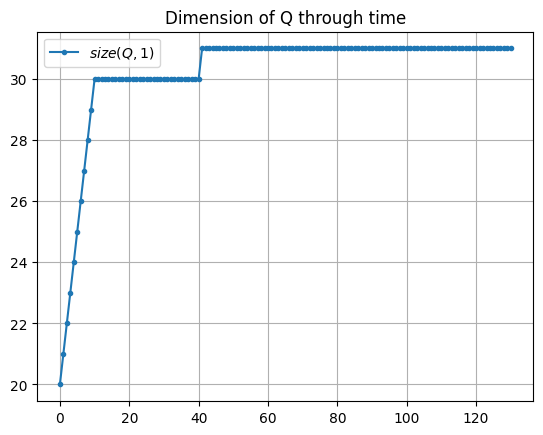

In [4]:
plt.plot(dimQ, marker='.', label="${size}(Q,1)$" )
plt.title("Dimension of Q through time")
plt.grid()
plt.legend()

Text(0.5, 1.0, 'When Q was exapnded')

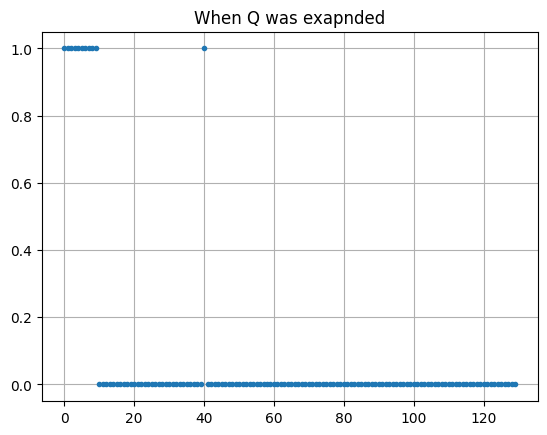

In [5]:
dimQ = np.array(dimQ)
diff = dimQ[1:]-dimQ[:-1]
plt.plot(diff, marker=".", ls="")
plt.grid()
plt.title("When Q was exapnded")

In [6]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

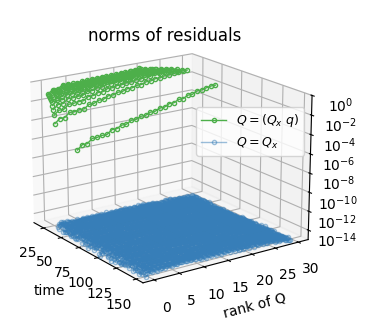

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.ticker as mticker

fig = plt.figure(figsize=(4, 5.6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(azim=-35, elev=18)

br1 = 0
br2 = 0
for i, arr in enumerate(all_rez):
    x = np.full_like(arr, i+20)  # x
    y = np.arange(len(arr))   # y  
    z = np.log10(arr) # z

    if(diff[i] == 1):
        if(br1 == 0):
            ax.plot(x, y, z, marker='.',markerfacecolor="None", linewidth=1, color=CB_color_cycle[2], label="$Q = (Q_x \ q)$", zorder=10, ls="-")
            br1=1
        else:
            ax.plot(x, y, z, marker='.',markerfacecolor="None", linewidth=1, color=CB_color_cycle[2], zorder=10, ls="-")
    else:
        if(br2 == 0):
            ax.plot(x, y, z, marker='.',markerfacecolor="None", linewidth=1, color=CB_color_cycle[0], label="$Q = Q_x$", alpha=0.5, ls="-")
            br2=1
        else:
            ax.plot(x, y, z, marker='.',markerfacecolor="None", linewidth=1, color=CB_color_cycle[0], alpha=0.5, ls="-")
    
ax.set_zlim(-15, 0)
def log_tick_formatter(val, pos=None):
    return f"$10^{{{int(val)}}}$"

ax.zaxis.set_major_formatter(mticker.FuncFormatter(log_tick_formatter))
ax.zaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xlabel('time', fontsize=10)
ax.set_ylabel('rank of Q')
plt.legend(loc=(0.6, 0.53), fontsize=9)
plt.title("norms of residuals", y=0.95)
plt.show()